In [1]:
import mujoco as mj
import mediapy as media
def render(model, data=None, height=300, camera=-1):
  if data is None:
    data = mj.MjData(model)
  with mj.Renderer(model, 480, 640) as renderer:
    mj.mj_forward(model, data)
    renderer.update_scene(data, camera="closeup")
    media.show_image(renderer.render(), height=height)

from IPython.display import clear_output, HTML, display
clear_output()

import pygments
def print_xml(xml_string):
  formatter = pygments.formatters.HtmlFormatter()
  lexer = pygments.lexers.XmlLexer()
  highlighted = pygments.highlight(xml_string, lexer, formatter)
  display(HTML(f"<style>{formatter.get_style_defs()}</style>{highlighted}"))

In [2]:
#@title Parse, compile, modify, compile: {vertical-output: true}

static_model = """
<mujoco model="v2_4">
    <compiler angle="radian"/>
    <option timestep="0.001" iterations="2000" gravity="0 0 -9.8" tolerance="1e-10"/>
    
    <default>
        <geom density="418"/>
    </default>

    <asset>
        <texture name="grid" type="2d" builtin="checker" rgb1=".1 .2 .3"
            rgb2=".2 .3 .4" width="300" height="300"/>
        <material name="grid" texture="grid" texrepeat="8 8" reflectance=".2"/>
    </asset>

    <worldbody>
        <light name="top" pos="0 0 5" diffuse="1 1 1" ambient="0.5 0.5 0.5"/>
        <camera name="closeup" pos="1.483 -0.033 0.580" xyaxes="0.040 0.999 -0.000 -0.129 0.005 0.992"/>

        <geom size="10 10 .01" type="plane" material="grid" friction="1 0.005 0.0001"/>

        <body name="Base" pos="0 0 0.8">
            <geom size="0.01 0.2 0.01" type="box" rgba="0.8 0 0 0.8" mass="0.155" contype="0" conaffinity="0"/>
            <body name="RB_Thigh" pos="0 0 0">
                <geom size="0.005" type="capsule" rgba="0.8 0 0 0.8" mass="0.086" fromto="0 0 0 0 0 -0.25" contype="0" conaffinity="0"/>
                <joint name="RB_Shoulder" type="hinge" axis="1 0 0" range="-1.57 1.57"/>
                <body name="RB_Calf" pos="0 0 -0.25">
                    <geom size="0.005" type="capsule" rgba="0.8 0 0 0.8" mass="0.1033" fromto="0 0 0 0 0 -0.25" contype="0" conaffinity="0"/>
                    <joint name="RB_Elbow" type="hinge" axis="1 0 0" range="-1.57 1.57"/>
                    <body name="Leg" pos="0 0 -0.25">
                        <geom size="0.005" type="capsule" rgba="0.8 0 0 0.8" mass="0.1033" fromto="0 0 0 0 0 -0.25" contype="0" conaffinity="0"/>
                        <joint name="Leg_joint" type="hinge" axis="1 0 0" range="-1.57 1.57"/>
                    </body>
                    <body name="Leg_RB_BAA_UPLink" pos="0 0.1 -0.1" axisangle="1 0 0 -0.1973955598">
                        <geom size="0.005" type="sphere" rgba="0.5 0.5 0 0.8" mass="0.03" contype="0" conaffinity="0"/>
                        <site name="Leg_RB_BAA_anchor1" pos="0 0 0"/>
                        <joint name="Leg_RB_BAA_UPJoint" type="hinge" axis="1 0 0"/>
                        <body name="Leg_RB_BAA_FMLink" pos="0 0 -0.1274754878">
                            <geom size="0.005" type="sphere" rgba="0.5 0.5 0 0.8" mass="0.12" contype="0" conaffinity="0"/>
                            <joint name="Leg_RB_BAA_SlideJoint" type="slide" axis="0 0 -1" damping="0" stiffness="0" springref="0"/>
                            <body name="Leg_RB_BAA_LOLink" pos="0 0 -0.1274754878">
                                <geom size="0.005" type="sphere" rgba="0.5 0.5 0 0.8" mass="0.03" contype="0" conaffinity="0"/>
                                <joint name="Leg_RB_BAA_FM_SlideJoint" type="slide" axis="0 0 -1" damping="0" stiffness="0" springref="0"/>
                                <site name="Leg_RB_BAA_anchor2" pos="0 0 0"/>
                            </body>
                        </body>
                    </body>
                </body>
               
            </body>
            <body name="RB_MAA_UPLink" pos="0 -0.06 0" axisangle="1 0 0 0.1419014548">
                <geom size="0.005" type="sphere" rgba="0.8 0 0 0.8" mass="0.03108" contype="0" conaffinity="0"/>
                <site name="RB_MAA_anchor1" pos="0 0 0"/>
                <joint name="RB_MAA_UpJoint" type="hinge" axis="1 0 0"/>
                <body name="RB_MAA_FM_Link" pos="0 0 -0.1060650937413537">
                    <geom size="0.005" type="sphere" rgba="0.8 0 0 0.8" mass="0.12432" contype="0" conaffinity="0"/>
                    <joint name="RB_MAA_SlideJoint" type="slide" axis="0 0 -1" damping="22.68" stiffness="637.52" springref="-0.019065093741353706"/>
                    <body name="RB_MAA_LOLink" pos="0 0 -0.1060650937413537">
                        <geom size="0.005" type="sphere" rgba="0.8 0 0 0.8" mass="0.03108" contype="0" conaffinity="0"/>
                        <joint name="RB_MAA_FM_SlideJoint" type="slide" axis="0 0 -1" damping="22.68" stiffness="637.52" springref="-0.019065093741353706"/>
                        <site name="RB_MAA_anchor2" pos="0 0 0"/>
                    </body>
                </body>
            </body>
            <body name="RB_BAA_UPLink" pos="0 0.1 0" axisangle="1 0 0 -0.147464847">
                <geom size="0.005" type="sphere" rgba="0 0 0.5 0.8" mass="0.04544333333" contype="0" conaffinity="0"/>
                <site name="RB_BAA_anchor1" pos="0 0 0"/>
                <joint name="RB_BAA_UpJoint" type="hinge" axis="1 0 0"/>
                <body name="RB_BAA_FM_LINK" pos="0 0 -0.17014792842496052">
                    <geom size="0.005" type="sphere" rgba="0 0 0.5 0.8" mass="0.1817733333" contype="0" conaffinity="0"/>
                    <joint name="RB_BAA_SlideJoint" type="slide" axis="0 0 -1" damping="21.8" stiffness="631.6" springref="-0.04204792842496052"/>
                    <body name="RB_BAA_LOLink" pos="0 0 -0.17014792842496052">
                        <geom size="0.005" type="sphere" rgba="0 0 0.5 0.8" mass="0.04544333333" contype="0" conaffinity="0"/>
                        <joint name="RB_BAA_FM_SlideJoint" type="slide" axis="0 0 -1" damping="21.8" stiffness="631.6" springref="-0.04204792842496052"/>
                        <site name="RB_BAA_anchor2" pos="0 0 0"/>
                    </body>
                </body>
            </body>
        </body>

    </worldbody>

          <!-- 增加在RB_RB_BAA_LowerJoint等关节中加入8个位置控制器，要求增加位置限制 -->
    <actuator>
        <motor joint="RB_MAA_SlideJoint" ctrllimited="true" ctrlrange="-200 200" />
        <motor joint="RB_MAA_FM_SlideJoint" ctrllimited="true" ctrlrange="-200 200" />
        <motor joint="RB_BAA_SlideJoint" ctrllimited="true" ctrlrange="-200 200" />
        <motor joint="RB_BAA_FM_SlideJoint" ctrllimited="true" ctrlrange="-200 200" />
        <motor joint="Leg_RB_BAA_SlideJoint" ctrllimited="true" ctrlrange="-200 200" />
        <motor joint="Leg_RB_BAA_FM_SlideJoint" ctrllimited="true" ctrlrange="-200 200" />
    </actuator>

    <!-- 建立并联关系，如 RB_RB_BAA_LOLink 应该与 RB_Calf 连接 --> 
    <equality>
        <connect name="RB_BAA_connect" anchor="0 0 0" body2="RB_Calf" body1="RB_BAA_LOLink" solimp="0.95 0.99 0.00001 0.1 2"/>
        <connect name="RB_MAA_connect" anchor="0 0 0" body2="RB_Thigh" body1="RB_MAA_LOLink" solimp="0.95 0.99 0.00001 0.1 2"/>
        <connect name="Leg_RB_BAA_connect" anchor="0 0 0" body2="Leg" body1="Leg_RB_BAA_LOLink" solimp="0.95 0.99 0.00001 0.1 2"/>
        
        <!-- FM 的相等约束 -->
        <joint name="MAA" joint1="RB_MAA_SlideJoint" joint2="RB_MAA_FM_SlideJoint" solimp="0.95 0.99 0.00001 0.1 2"/>
        <joint name="BAA" joint1="RB_BAA_SlideJoint" joint2="RB_BAA_FM_SlideJoint" solimp="0.95 0.99 0.00001 0.1 2"/>
        <joint name="Leg_RB_BAA" joint1="Leg_RB_BAA_SlideJoint" joint2="Leg_RB_BAA_FM_SlideJoint" solimp="0.95 0.99 0.00001 0.1 2"/>
    </equality>

    <!-- visualization -->
    <tendon>
        <spatial stiffness="0" width="0.003">
            <site site="RB_MAA_anchor1"/>
            <site site="RB_MAA_anchor2"/>
        </spatial>
        <spatial stiffness="0" width="0.003">
            <site site="RB_BAA_anchor1"/>
            <site site="RB_BAA_anchor2"/>
        </spatial>
        <spatial stiffness="0" width="0.003">
            <site site="Leg_RB_BAA_anchor1"/>
            <site site="Leg_RB_BAA_anchor2"/>
        </spatial>
    </tendon>

</mujoco>
"""


In [ ]:

spec = mj.MjSpec.from_string(static_model)
model = spec.compile()
render(model)

# Change the mjSpec, re-compile and re-render
spec.modelname = "edited model"

# add body and geom
name = 'thigh_body'
pos = [0, 0, 0]
axisangle = [1, 0, 0, 0]

thigh_body = spec.worldbody.add_body(name=name, pos=pos, axisangle=axisangle)

# add geom
name = 'test_geom'
size = [0.005, 0, 0]
type = mj.mjtGeom.mjGEOM_SPHERE
rgba = [0.8, 0, 0, 0.8]
mass = 0.03108
contype = 0
conaffinity = 0
thigh_body.add_geom(name=name, type=type, size=size, rgba=rgba, mass=mass, contype=contype, conaffinity=conaffinity)

# add tendon
name = 'test_tendon'
stiffness = 0.0
width = 0.003
thread = spec.add_tendon(name=name, stiffness=stiffness, width=width)
thread.wrap_site('RB_MAA_anchor1')
thread.wrap_site('Leg_RB_BAA_anchor1')

# add equality
name = 'test_equality'
joint1 = 'RB_MAA_SlideJoint'
joint2 = 'RB_MAA_FM_SlideJoint'
solimp = [0.95, 0.99, 0.00001, 0.1, 2]
spec.add_equality(name=name, type =mj.mjtEq.mjEQ_JOINT, name1=joint1, name2=joint2, solimp=solimp)

model = spec.compile()
render(model)
print_xml(spec.to_xml())

In [3]:
# build a basic element of 3 segment muscle like this
'''
<body name="RB_BAA_UPLink" pos="0 0.1 0" axisangle="1 0 0 -0.147464847">
    <geom size="0.005" type="sphere" rgba="0 0 0.5 0.8" mass="0.04544333333" contype="0" conaffinity="0"/>
    <site name="RB_BAA_anchor1" pos="0 0 0"/>
    <joint name="RB_BAA_UpJoint" type="hinge" axis="1 0 0"/>
    <body name="RB_BAA_FM_LINK" pos="0 0 -0.17014792842496052">
        <geom size="0.005" type="sphere" rgba="0 0 0.5 0.8" mass="0.1817733333" contype="0" conaffinity="0"/>
        <joint name="RB_BAA_SlideJoint" type="slide" axis="0 0 -1" damping="21.8" stiffness="631.6" springref="-0.04204792842496052"/>
        <body name="RB_BAA_LOLink" pos="0 0 -0.17014792842496052">
            <geom size="0.005" type="sphere" rgba="0 0 0.5 0.8" mass="0.04544333333" contype="0" conaffinity="0"/>
            <joint name="RB_BAA_FM_SlideJoint" type="slide" axis="0 0 -1" damping="21.8" stiffness="631.6" springref="-0.04204792842496052"/>
            <site name="RB_BAA_anchor2" pos="0 0 0"/>
        </body>
    </body>
</body>
'''

'\n<body name="RB_BAA_UPLink" pos="0 0.1 0" axisangle="1 0 0 -0.147464847">\n    <geom size="0.005" type="sphere" rgba="0 0 0.5 0.8" mass="0.04544333333" contype="0" conaffinity="0"/>\n    <site name="RB_BAA_anchor1" pos="0 0 0"/>\n    <joint name="RB_BAA_UpJoint" type="hinge" axis="1 0 0"/>\n    <body name="RB_BAA_FM_LINK" pos="0 0 -0.17014792842496052">\n        <geom size="0.005" type="sphere" rgba="0 0 0.5 0.8" mass="0.1817733333" contype="0" conaffinity="0"/>\n        <joint name="RB_BAA_SlideJoint" type="slide" axis="0 0 -1" damping="21.8" stiffness="631.6" springref="-0.04204792842496052"/>\n        <body name="RB_BAA_LOLink" pos="0 0 -0.17014792842496052">\n            <geom size="0.005" type="sphere" rgba="0 0 0.5 0.8" mass="0.04544333333" contype="0" conaffinity="0"/>\n            <joint name="RB_BAA_FM_SlideJoint" type="slide" axis="0 0 -1" damping="21.8" stiffness="631.6" springref="-0.04204792842496052"/>\n            <site name="RB_BAA_anchor2" pos="0 0 0"/>\n        </bo

In [8]:
# solve the actuator
import xml.etree.ElementTree as ET

def add_motors_to_spec(spec: mj.MjSpec, joints: list[str], 
                            ctrlrange=(-200, 200), gear=1.0, prefix="motor_") -> mj.MjSpec:
    """
    向 MjSpec 模型中添加 motor actuator（通过解析 XML 插入）。
    
    Args:
        spec: MjSpec 实例
        joints: 需要控制的 joint 名称列表
        ctrlrange: 控制范围，例如 (-200, 200)
        gear: motor gear 值
        prefix: motor 的命名前缀

    Returns:
        新构建的 MjSpec 对象，包含 motor actuator
    """
    xml_str = spec.to_xml()
    root = ET.fromstring(xml_str)

    # 查找或创建 <actuator> 节点
    actuator_node = root.find("actuator")
    if actuator_node is None:
        actuator_node = ET.SubElement(root, "actuator")

    # 添加 motor 控制器
    for joint_name in joints:
        motor = ET.SubElement(actuator_node, "motor")
        motor.set("name", prefix + joint_name)
        motor.set("joint", joint_name)
        motor.set("ctrllimited", "true")
        motor.set("ctrlrange", f"{ctrlrange[0]} {ctrlrange[1]}")
        motor.set("gear", str(gear))

    # 重新构造 spec
    modified_xml = ET.tostring(root, encoding="unicode")
    return mj.MjSpec.from_string(modified_xml)

""

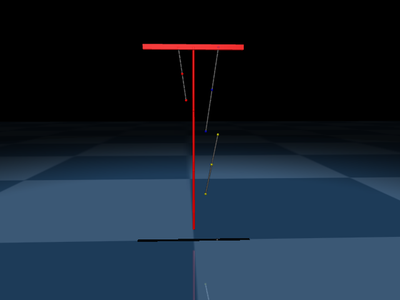

In [5]:
spec = mj.MjSpec.from_string(static_model)

# assume we have muscle_x
muscle_x = {
    'name': "muscleX",
    'mass': 0.18,
    'stiffness': 300,
    'damping': 0.5,
    'rest_length': 0.18,
}

_body = spec.worldbody.add_body(name=f"{muscle_x['name']}_uLink", 
                                pos=[0, 0.1, 0], axisangle=[1, 0, 0, -0.147464847])
_body.add_joint(name = f"{muscle_x['name']}_uRotJoint",
    type=mj.mjtJoint.mjJNT_HINGE,
    pos = [0, 0, 0],
    axis = [1, 0, 0])

_body.add_geom(name=f"{muscle_x['name']}_uGeom",
               type=mj.mjtGeom.mjGEOM_SPHERE,
               size=[0.005, 0, 0],
               mass = muscle_x['mass'] / 6,
               contype = 0,
               conaffinity = 0)

_body.add_site(name=f"{muscle_x['name']}_uSite", pos = [0, 0, 0])

# 迭代
_body = _body.add_body(name=f"{muscle_x['name']}_mLink", pos=[0, 0.1, 0])
_body.add_joint(name = f"{muscle_x['name']}_mSlideJoint",
    type=mj.mjtJoint.mjJNT_SLIDE,
    pos = [0, 0, 0],
    axis = [0, 0, -1],
    springref = 0.18,
    stiffness = muscle_x['stiffness'] * 2,
    damping = muscle_x['damping'] * 2,
    )

_body.add_geom(name=f"{muscle_x['name']}_mGeom",
               type=mj.mjtGeom.mjGEOM_SPHERE,
               size=[0.005, 0, 0],
               mass = muscle_x['mass'] * 2 / 3,
               contype = 0,
               conaffinity = 0)

_body.add_site(name=f"{muscle_x['name']}_mSite", pos = [0, 0, 0])

# 迭代
_body = _body.add_body(name=f"{muscle_x['name']}_lLink", pos=[0, 0.1, 0])
_body.add_joint(name = f"{muscle_x['name']}_lSlideJoint",
    type=mj.mjtJoint.mjJNT_SLIDE,
    pos = [0, 0, 0],
    axis = [0, 0, -1],
    springref = 0.18,
    stiffness = muscle_x['stiffness'] * 2,
    damping = muscle_x['damping'] * 2,
    )

_body.add_geom(name=f"{muscle_x['name']}_lGeom",
               type=mj.mjtGeom.mjGEOM_SPHERE,
               size=[0.005, 0, 0],
               mass = muscle_x['mass'] * 1 / 6,
               contype = 0,
               conaffinity = 0)

_body.add_site(name=f"{muscle_x['name']}_lSite", pos = [0, 0, 0])


print_xml(spec.to_xml())
model = spec.compile()
render(model)

In [18]:
DEFAULT_BALL_SIZE = 0.005     # for the mass point visualization

def add_muscle_to_spec(spec, muscle_cfg):
    # unpack
    name = muscle_cfg['name']
    mass = muscle_cfg['mass']
    stiffness = muscle_cfg['stiffness']
    damping = muscle_cfg['damping']
    rest_length = muscle_cfg['rest_length']
    init_length = muscle_cfg['init_length']
    # where it connects
    base_pos = muscle_cfg.get('base_pos')
    base_axisangle = muscle_cfg.get('base_axisangle')

    # preprocess
    uLink_mass, mLink_mass, lLink_mass = mass/6, mass*2/3, mass/6
    mSlideJoint_stiffness, lSlideJoint_stiffness = stiffness*2, stiffness*2
    mSlideJoint_damping, lSlideJoint_damping = damping*2, damping*2
    
    # NOTE: need to keep the axis of the muscle to be [0 0 -1] relative to the parent frame
    mLink_pos = [0, 0, -init_length/2]
    lLink_pos = [0, 0, -init_length/2]
    # NOTE: 'spring_ref' is the relative length of the muscle when it is at rest, to the init length
    init_relative_length = rest_length - init_length
    mSlideJoint_initRelaLength, lSlideJoint_initRelaLength = init_relative_length/2, init_relative_length/2

    # upper part
    _body = spec.add_body(name=f"{name}_uLink", pos=base_pos, axisangle=base_axisangle)
    print(f"base_axisangle: {base_axisangle}")
    _body.add_joint(name = f"{name}_uRotJoint",
        type=mj.mjtJoint.mjJNT_HINGE,
        pos = [0, 0, 0],
        axis = [1, 0, 0])
        # NOTE: we assume the motion is in the YOZ plane, so any rotate joint has a x-rotJoint
    _body.add_geom(name=f"{name}_uGeom",
                type=mj.mjtGeom.mjGEOM_SPHERE,
                size=[DEFAULT_BALL_SIZE, 0, 0],
                mass = uLink_mass,
                contype = 0,
                conaffinity = 0)
    _body.add_site(name=f"{name}_uSite", pos = [0, 0, 0])

    # middle part
    _body = _body.add_body(name=f"{name}_mLink", pos=mLink_pos)
    _body.add_joint(name = f"{name}_mSlideJoint",
        type=mj.mjtJoint.mjJNT_SLIDE,
        pos = [0, 0, 0],
        axis = [0, 0, -1],      
        # NOTE: need to keep the axis of the muscle to be [0 0 -1] relative to the parent frame
        springref = mSlideJoint_initRelaLength,
        stiffness = mSlideJoint_stiffness,
        damping = mSlideJoint_damping,
        )
    _body.add_geom(name=f"{name}_mGeom",
                type=mj.mjtGeom.mjGEOM_SPHERE,
                size=[DEFAULT_BALL_SIZE, 0, 0],
                mass = mLink_mass,
                # NOTE: ignore all collision in this theoretical verification
                contype = 0,
                conaffinity = 0)
    _body.add_site(name=f"{name}_mSite", pos = [0, 0, 0])

    # lower part
    _body = _body.add_body(name=f"{name}_lLink", pos=lLink_pos)
    _body.add_joint(name = f"{name}_lSlideJoint",
        type=mj.mjtJoint.mjJNT_SLIDE,
        pos = [0, 0, 0],
        axis = [0, 0, -1],
        springref = lSlideJoint_initRelaLength,
        stiffness = lSlideJoint_stiffness,
        damping = lSlideJoint_damping,
        )
    _body.add_geom(name=f"{name}_lGeom",
                type=mj.mjtGeom.mjGEOM_SPHERE,
                size=[DEFAULT_BALL_SIZE, 0, 0],
                mass = lLink_mass,
                contype = 0,
                conaffinity = 0)
    _body.add_site(name=f"{name}_lSite", pos = [0, 0, 0])

    # add actuators
    # _body.add_actuator(name=f"{name}_m

# 进行封装测试
spec = mj.MjSpec.from_string(static_model)

# assume we have muscle_x
muscleX_cfg = {
    'name': "muscleX",
    'mass': 0.27266,
    'stiffness': 315.8,
    'damping': 10.9,
    'init_length': 0.340296,
    'rest_length': 0.2562,
    'base_pos': [0, 0.1, 0],
    'base_axisangle': [1, 0, 0, -0.147464847],
}


# add_muscle_to_spec(spec.worldbody, muscleX_cfg)
# add_muscle_to_spec(spec.body("RB_Calf"), muscleX_cfg)


DEFAULT_TENDON_SIZE = 0.003
DEFAULT_TENDON_STIFFNESS = 0

def add_tendon_to_spec(spec, tendon_cfg):
    name = tendon_cfg['name']
    width = tendon_cfg['width']
    stiffness = tendon_cfg['stiffness']
    site1_name = tendon_cfg['site1_name']
    site2_name = tendon_cfg['site2_name']

    _tendon = spec.add_tendon(name=name, stiffness=stiffness, width=width)
    _tendon.wrap_site(site1_name)
    _tendon.wrap_site(site2_name)

# tendon_cfg = {
#     'name': "tendonX",
#     'width': DEFAULT_TENDON_SIZE,
#     'stiffness': DEFAULT_TENDON_STIFFNESS,
#     'site1_name': "muscleX_uSite",
#     'site2_name': "muscleX_lSite",
# }

# add_tendon_to_spec(spec, tendon_cfg)

def add_equality_spec(spec, equality_cfg):
    ''' Add an equality constraint to the spec. Joint equality is used to enforce the equality of two joints. '''
    name = equality_cfg['name']
    type = equality_cfg['type']
    name1 = equality_cfg['name1']
    name2 = equality_cfg['name2']
    solimp = equality_cfg['solimp']
    spec.add_equality(name=name, type=type, name1=name1, name2=name2, solimp=solimp)

# equality_cfg = {
#     'name': 'test_equality',
#     'type': mj.mjtEq.mjEQ_JOINT,
#     'name1': 'RB_MAA_SlideJoint',
#     'name2': 'RB_MAA_FM_SlideJoint',
#     'solimp': [0.95, 0.99, 0.00001, 0.1, 2],
# }

# add_equality_spec(spec, equality_cfg)

# spec.add_equality(name='connect', type=mj.mjtEq.mjEQ_CONNECT, name1='RB_BAA_LOLink', name2='RB_Calf', solimp=[0.95, 0.99, 0.00001, 0.1, 2], objtype=mj.mjtObj.mjOBJ_BODY)

# # spec.equality("connect").anchor = [0, 0, 0]  # Set the anchor point for the connect equality

# print_xml(spec.to_xml())
# model = spec.compile()
# render(model)

In [ ]:
# 强行修改anchor为000
xml_str = spec.to_xml()


import xml.etree.ElementTree as ET

# 假设 xml_str 是你的 XML 字符串
root = ET.fromstring(xml_str)

# 遍历所有 connect 标签
for conn in root.findall(".//connect"):
    conn.set("anchor", "0 0 0")

# 写回为字符串
xml_str_modified = ET.tostring(root, encoding='unicode')

new_spec = mj.MjSpec.from_string(xml_str_modified)
print_xml(new_spec.to_xml())

In [ ]:
base_body = spec.body("Base")

In [ ]:
_body = spec.body('RB_BAA_LOLink')

# Final Build

In [6]:
static_model = '''
<mujoco model="v2_4">
    <compiler angle="radian"/>
    <option timestep="0.001" iterations="2000" gravity="0 0 -9.8" tolerance="1e-10"/>
    
    <default>
        <geom density="418"/>
    </default>

    <asset>
        <texture name="grid" type="2d" builtin="checker" rgb1=".1 .2 .3"
            rgb2=".2 .3 .4" width="300" height="300"/>
        <material name="grid" texture="grid" texrepeat="8 8" reflectance=".2"/>
    </asset>

    <worldbody>
        <light name="top" pos="0 0 5" diffuse="1 1 1" ambient="0.5 0.5 0.5"/>
        <camera name="closeup" pos="1.483 -0.033 0.580" xyaxes="0.040 0.999 -0.000 -0.129 0.005 0.992"/>
        <geom size="10 10 .01" type="plane" material="grid" friction="1 0.005 0.0001"/>

        <body name="Base" pos="0 0 0.8">
            <geom size="0.01 0.2 0.01" type="box" rgba="0.8 0 0 0.8" mass="0.155" contype="0" conaffinity="0"/>
        </body>
    </worldbody>

</mujoco>
'''

base_axisangle: [1, 0, 0, 0.1419014548]
base_axisangle: [1, 0, 0, -0.147464847]


""

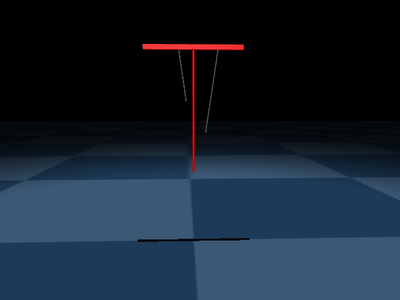

In [43]:
import random
spec = mj.MjSpec.from_string(static_model)

base_body = spec.body('Base')

# Step 1: build random bone-like rigid links (ofc, and bodies)

link_lengths = [0.25] * 2
link_masses = [0.155] * 2

for i in range(len(link_lengths)):
    link_name = 'link' + str(i) + '_body'
    geom_name = 'link' + str(i) + '_geom'
    mass = link_masses[i]
    if i == 0: 
        pos = [0, 0, 0]         # For Link0, its parents link is the base body
        _body = base_body.add_body(name=link_name, pos=pos)
    else: 
        pos = [0, 0, -link_lengths[i-1]]
        parent_link_name = 'link' + str(i-1) + '_body'
        parent_link_body = spec.body(parent_link_name)
        _body = parent_link_body.add_body(name=link_name, pos=pos)
    # add geom
    _body.add_geom(name=geom_name, size=[0.005, 0, 0], type=mj.mjtGeom.mjGEOM_CAPSULE, rgba=[0.8, 0, 0, 0.8], mass=mass, fromto = [0, 0, 0, 0, 0, -link_lengths[i-1]], contype=0, conaffinity=0)
    # add joint
    _body.add_joint(name='link' + str(i) + '_joint', type=mj.mjtJoint.mjJNT_HINGE, pos=[0, 0, 0], axis=[1, 0, 0], range=[-1.57, 1.57])


# Step 2: build random muscles to linked them

def add_muscle_fromto(spec, start_body_name, end_body_name, muscle_cfg):
    # TODO: Base manually here
    start_body = spec.body(start_body_name)
    add_muscle_to_spec(start_body, muscle_cfg)

    tendon_cfg = {
        'name': f"tendon_{muscle_cfg['name']}",
        'width': DEFAULT_TENDON_SIZE,
        'stiffness': DEFAULT_TENDON_STIFFNESS,
        'site1_name': f"{muscle_cfg['name']}_uSite",
        'site2_name': f"{muscle_cfg['name']}_lSite",
    }
    add_tendon_to_spec(spec, tendon_cfg)

    equality_cfg = {
        'name': f"{muscle_cfg['name']}_equality",
        'type': mj.mjtEq.mjEQ_JOINT,
        'name1': f"{muscle_cfg['name']}_mSlideJoint",
        'name2': f"{muscle_cfg['name']}_lSlideJoint",
        'solimp': [0.95, 0.99, 0.00001, 0.1, 2],
    }
    add_equality_spec(spec, equality_cfg)

    spec.add_equality(name=f"_{muscle_cfg['name']}_equality_connect", type=mj.mjtEq.mjEQ_CONNECT, name1=f"{muscle_cfg['name']}_lLink", name2=end_body_name, solimp=[0.95, 0.99, 0.00001, 0.1, 2], objtype=mj.mjtObj.mjOBJ_BODY)

    muscle_jnt_names = [f"{muscle_cfg['name']}_mSlideJoint", f"{muscle_cfg['name']}_lSlideJoint"]
    spec_new = add_motors_to_spec(spec, muscle_jnt_names, ctrlrange=(-200, 200), gear=1.0, prefix='motor_')
    return spec_new


# add muscle
muscle1_cfg = {
    'name': "muscle1",
    'mass': 0.18648,
    'stiffness': 318.76,
    'damping': 11.34,
    'init_length': 0.2121301875,
    'rest_length': 0.174,
    'base_pos': [0, -0.06, 0],
    'base_axisangle': [1, 0, 0, 0.1419014548],
}

# add_muscle_to_spec(base_body, muscle1_cfg)

muscle2_cfg = {
    'name': "muscle2",
    'mass': 0.27266,
    'stiffness': 315.8,
    'damping': 10.9,
    'init_length': 0.340296,
    'rest_length': 0.2562,
    'base_pos': [0, 0.1, 0],
    'base_axisangle': [1, 0, 0, -0.147464847],
}



# add_muscle_to_spec(base_body, muscle2_cfg)

# tendon_cfg = {
#     'name': "tendon1",
#     'width': DEFAULT_TENDON_SIZE,
#     'stiffness': DEFAULT_TENDON_STIFFNESS,
#     'site1_name': "muscle1_uSite",
#     'site2_name': "muscle1_lSite",
# }

# add_tendon_to_spec(spec, tendon_cfg)

# tendon_cfg = {
#     'name': "tendon2",
#     'width': DEFAULT_TENDON_SIZE,
#     'stiffness': DEFAULT_TENDON_STIFFNESS,
#     'site1_name': "muscle2_uSite",
#     'site2_name': "muscle2_lSite",
# }

# add_tendon_to_spec(spec, tendon_cfg)

# for i in range(2):
#     id = i+1
#     equality_cfg = {
#         'name': f'muscle{id}_equality',
#         'type': mj.mjtEq.mjEQ_JOINT,
#         'name1': f'muscle{id}_mSlideJoint',
#         'name2': f'muscle{id}_lSlideJoint',
#         'solimp': [0.95, 0.99, 0.00001, 0.1, 2],
#     }

#     add_equality_spec(spec, equality_cfg)


# # add actuator
# muscle_jnt_names = ["muscle1_mSlideJoint", "muscle1_lSlideJoint", "muscle2_mSlideJoint", "muscle2_lSlideJoint"]
# spec = add_motors_to_spec(spec, muscle_jnt_names, ctrlrange=(-200, 200), gear=1.0, prefix='motor_')


# # add connect equality
# spec.add_equality(name='_connect1', type=mj.mjtEq.mjEQ_CONNECT, name1='muscle1_lLink', name2='link0_body', solimp=[0.95, 0.99, 0.00001, 0.1, 2], objtype=mj.mjtObj.mjOBJ_BODY)
# spec.add_equality(name='_connect2', type=mj.mjtEq.mjEQ_CONNECT, name1='muscle2_lLink', name2='link1_body', solimp=[0.95, 0.99, 0.00001, 0.1, 2], objtype=mj.mjtObj.mjOBJ_BODY)

# muscle3_cfg = muscle1_cfg.copy()
# muscle3_cfg['name'] = 'muscle3'
# base_body = spec.body('start_body')

# spec = add_muscle_fromto(spec, 'Base', 'link2_body', muscle3_cfg)
spec = add_muscle_fromto(spec, 'Base', 'link0_body', muscle1_cfg)
spec = add_muscle_fromto(spec, 'Base', 'link1_body', muscle2_cfg)

# fix the anchor
# 强行修改anchor为000
xml_str = spec.to_xml()
import xml.etree.ElementTree as ET
# 假设 xml_str 是你的 XML 字符串
root = ET.fromstring(xml_str)
# 遍历所有 connect 标签
for conn in root.findall(".//connect"):
    conn.set("anchor", "0 0 0")
# 写回为字符串
xml_str_modified = ET.tostring(root, encoding='unicode')
spec = mj.MjSpec.from_string(xml_str_modified)


# Step 3: check the topology
model = spec.compile()
render(model)
print_xml(spec.to_xml())

# save xml
xml_script = spec.to_xml()
with open(f'test.xml', 'w') as f:
    f.write(xml_script)